In [ ]:
# CUSTOMER SEGMENTATION

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [ ]:
df=pd.read_csv("/content/classification project data set customer.csv")
df

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Region,Marital_Status,Num_of_Children,Employment_Status,Credit_Score,Online_Shopping_Frequency,Target
0,CUST_1,25,Female,66041,15.0,South,Widowed,1.0,Unemployed,332,12.0,0
1,CUST_2,66,Male,46937,39.0,South,Single,0.0,Retired,550,4.0,0
2,CUST_3,18,Male,142885,65.0,South,Single,2.0,Retired,503,7.0,0
3,CUST_4,19,Female,146383,91.0,South,Divorced,0.0,Unemployed,759,9.0,0
4,CUST_5,57,Male,47686,47.0,West,Widowed,4.0,Retired,598,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,CUST_29996,44,Male,144527,21.0,South,Divorced,1.0,Employed,352,15.0,0
29996,CUST_29997,52,Female,23073,84.0,West,Single,2.0,Retired,518,5.0,0
29997,CUST_29998,46,Male,39075,57.0,West,Divorced,1.0,Retired,785,6.0,0
29998,CUST_29999,54,Female,22776,16.0,South,Divorced,3.0,Unemployed,469,2.0,0


In [ ]:
df.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Region,Marital_Status,Num_of_Children,Employment_Status,Credit_Score,Online_Shopping_Frequency,Target
0,CUST_1,25,Female,66041,15.0,South,Widowed,1.0,Unemployed,332,12.0,0
1,CUST_2,66,Male,46937,39.0,South,Single,0.0,Retired,550,4.0,0
2,CUST_3,18,Male,142885,65.0,South,Single,2.0,Retired,503,7.0,0
3,CUST_4,19,Female,146383,91.0,South,Divorced,0.0,Unemployed,759,9.0,0
4,CUST_5,57,Male,47686,47.0,West,Widowed,4.0,Retired,598,0.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                30000 non-null  object 
 1   Age                        30000 non-null  int64  
 2   Gender                     30000 non-null  object 
 3   Annual_Income              30000 non-null  int64  
 4   Spending_Score             29999 non-null  float64
 5   Region                     30000 non-null  object 
 6   Marital_Status             30000 non-null  object 
 7   Num_of_Children            29999 non-null  float64
 8   Employment_Status          30000 non-null  object 
 9   Credit_Score               30000 non-null  int64  
 10  Online_Shopping_Frequency  29999 non-null  float64
 11  Target                     30000 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 2.7+ MB


In [ ]:
df.isna().sum()

,0
Customer_ID,0
Age,0
Gender,0
Annual_Income,0
Spending_Score,1
Region,0
Marital_Status,0
Num_of_Children,1
Employment_Status,0
Credit_Score,0


In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Spending_Score',
       'Region', 'Marital_Status', 'Num_of_Children', 'Employment_Status',
       'Credit_Score', 'Online_Shopping_Frequency', 'Target'],
      dtype='object')

In [ ]:
df["Spending_Score"].fillna(df["Spending_Score"].median(),inplace=True)
df["Num_of_Children"].fillna(df["Num_of_Children"].median(),inplace=True)
df['Online_Shopping_Frequency'].fillna(df["Online_Shopping_Frequency"].median(),inplace=True)


/tmp/ipython-input-3059783395.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Spending_Score"].fillna(df["Spending_Score"].median(),inplace=True)
/tmp/ipython-input-3059783395.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [ ]:
df.isna().sum()

,0
Customer_ID,0
Age,0
Gender,0
Annual_Income,0
Spending_Score,0
Region,0
Marital_Status,0
Num_of_Children,0
Employment_Status,0
Credit_Score,0


In [ ]:
df["Spending_Score"]=df["Spending_Score"].astype(int)
df["Num_of_Children"]=df['Num_of_Children'].astype(int)
df["Online_Shopping_Frequency"]=df['Online_Shopping_Frequency'].astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Customer_ID                30000 non-null  object
 1   Age                        30000 non-null  int64 
 2   Gender                     30000 non-null  object
 3   Annual_Income              30000 non-null  int64 
 4   Spending_Score             30000 non-null  int64 
 5   Region                     30000 non-null  object
 6   Marital_Status             30000 non-null  object
 7   Num_of_Children            30000 non-null  int64 
 8   Employment_Status          30000 non-null  object
 9   Credit_Score               30000 non-null  int64 
 10  Online_Shopping_Frequency  30000 non-null  int64 
 11  Target                     30000 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 2.7+ MB


In [ ]:
df.drop('Customer_ID', axis=1, inplace=True)


In [ ]:
# EDA

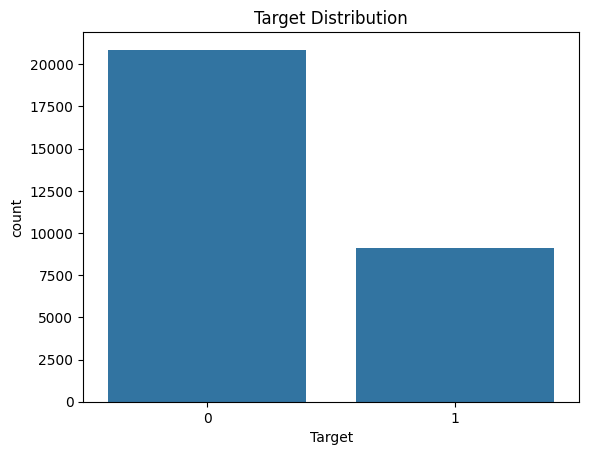

In [ ]:
sns.countplot(x='Target', data=df)
plt.title("Target Distribution")
plt.show()


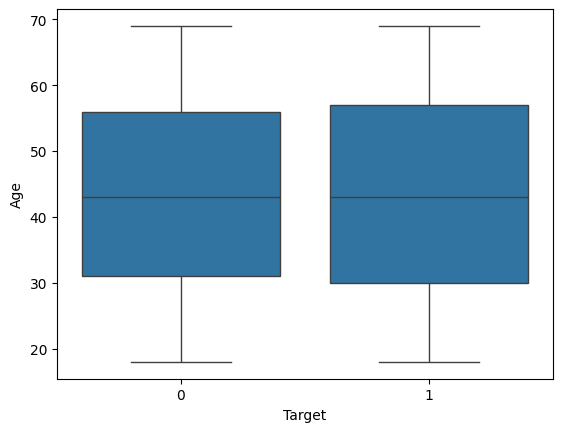

In [ ]:
sns.boxplot(x='Target', y='Age', data=df)
plt.show()


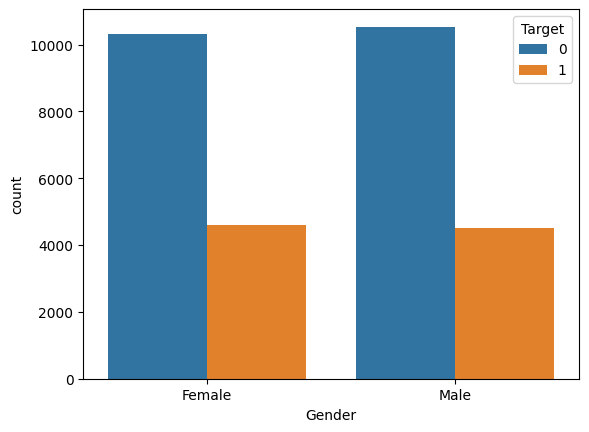

In [ ]:
sns.countplot(x='Gender', hue='Target', data=df)
plt.show()


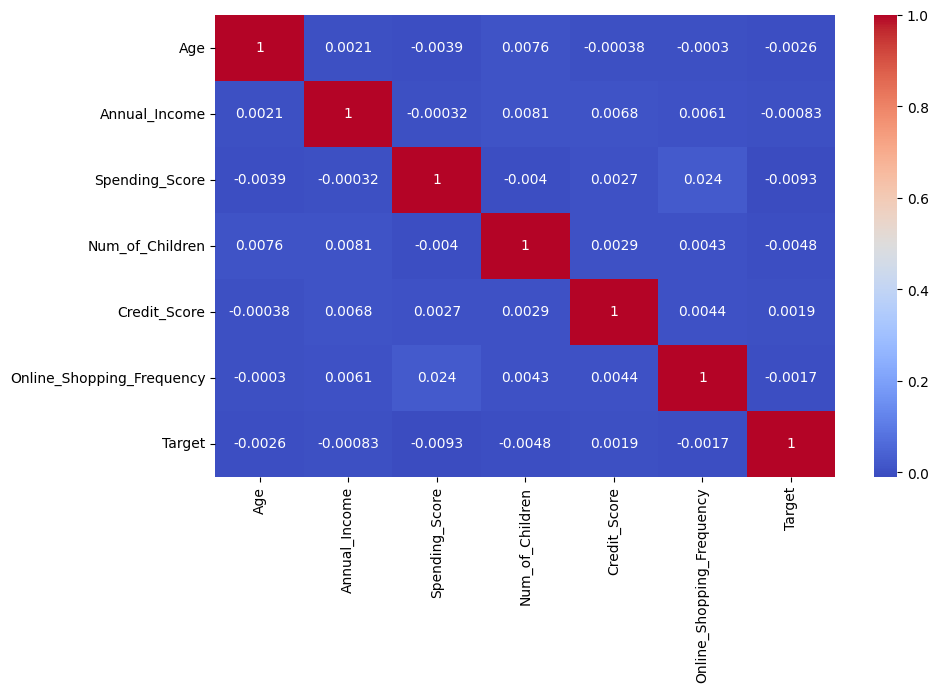

In [ ]:
# correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()


In [ ]:
le=LabelEncoder()
cat_col=['Gender', 'Region', 'Marital_Status', 'Employment_Status']
for col in cat_col:
  df[col]=le.fit_transform(df[col])

In [ ]:
x=df.drop('Target',axis=1)
y=df['Target']


In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=.3,random_state=42)

In [ ]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

y_pred_lr= lr.predict(x_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.6967777777777778


In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred_knn=knn.predict(x_test)
print("KNN Accuracy:", accuracy_score(y_test,y_pred_knn))


KNN Accuracy: 0.6324444444444445


In [ ]:
nb = GaussianNB()
nb.fit(x_train, y_train)

y_pred_nb= nb.predict(x_test)
print("Naive Bayes Accuracy:",accuracy_score(y_test,y_pred_nb))


Naive Bayes Accuracy: 0.6967777777777778


In [ ]:
rf= RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

y_pred_rf = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.6918888888888889


In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.6967777777777778


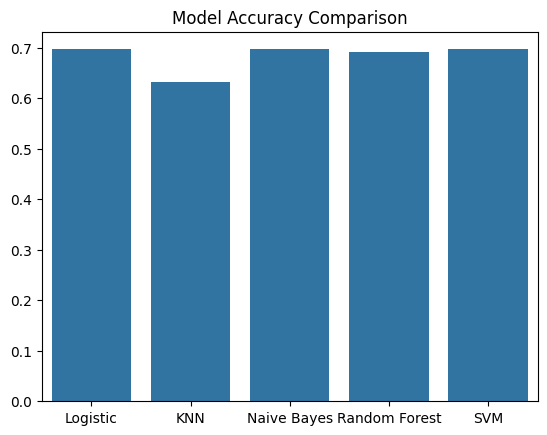

In [ ]:
models = ['Logistic', 'KNN', 'Naive Bayes', 'Random Forest', 'SVM']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]

sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.show()


In [ ]:
new_customer = pd.DataFrame({
    'Age': [30],
    'Gender': [1],
    'Annual_Income': [50000],
    'Spending_Score': [60],
    'Region': [2],
    'Marital_Status': [1],
    'Num_of_Children': [1],
    'Employment_Status': [0],
    'Credit_Score': [650],
    'Online_Shopping_Frequency': [8]
})

new_customer_scaled = scaler.transform(new_customer)
prediction = rf.predict(new_customer_scaled)

print("Prediction:", prediction)


Prediction: [0]
